In [2]:
import pandas as pd
import sqlite3

file_name = 'googleplaystore.csv'
df = pd.read_csv('googleplaystore.csv')


conn = sqlite3.connect('playstore.db')


df.to_sql('apps_table', conn, if_exists='replace', index=False)

print("Game data \n")


query = "SELECT App, Category, Rating, Installs, Price FROM apps_table LIMIT 5;"
sql_data = pd.read_sql_query(query, conn)

sql_data

Game data 



,App,Category,Rating,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,"10,000+",0
1,Coloring book moana,ART_AND_DESIGN,3.9,"500,000+",0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,"5,000,000+",0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,"50,000,000+",0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,"100,000+",0


In [3]:

#data cleaning
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)

df = df[df['Installs'] != 'Free']


df['Installs'] = df['Installs'].astype('int64')


df.to_sql('apps_table', conn, if_exists='replace', index=False)

print("data clean succ \n")


query = "SELECT App, Installs FROM apps_table LIMIT 5;"
print(pd.read_sql_query(query, conn))

data clean succ 

                                                 App  Installs
0     Photo Editor & Candy Camera & Grid & ScrapBook     10000
1                                Coloring book moana    500000
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   5000000
3                              Sketch - Draw & Paint  50000000
4              Pixel Draw - Number Art Coloring Book    100000


In [4]:
print("Data Preprocessing & Transformation Completed Successfully. ")
print("Executing SQL Aggregation Query...\n")


query_category = """
SELECT 
    Category, 
    SUM(Installs) AS Total_Installs 
FROM apps_table 
GROUP BY Category 
ORDER BY Total_Installs DESC 
LIMIT 5;
"""

top_categories = pd.read_sql_query(query_category, conn)
top_categories

Data Preprocessing & Transformation Completed Successfully. 
Executing SQL Aggregation Query...



,Category,Total_Installs
0,GAME,35086024415
1,COMMUNICATION,32647276251
2,PRODUCTIVITY,14176091369
3,SOCIAL,14069867902
4,TOOLS,11452771915


Generating Visualizations for Market Insights... 



C:\Users\yashg\AppData\Local\Temp\ipykernel_5700\3130879725.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


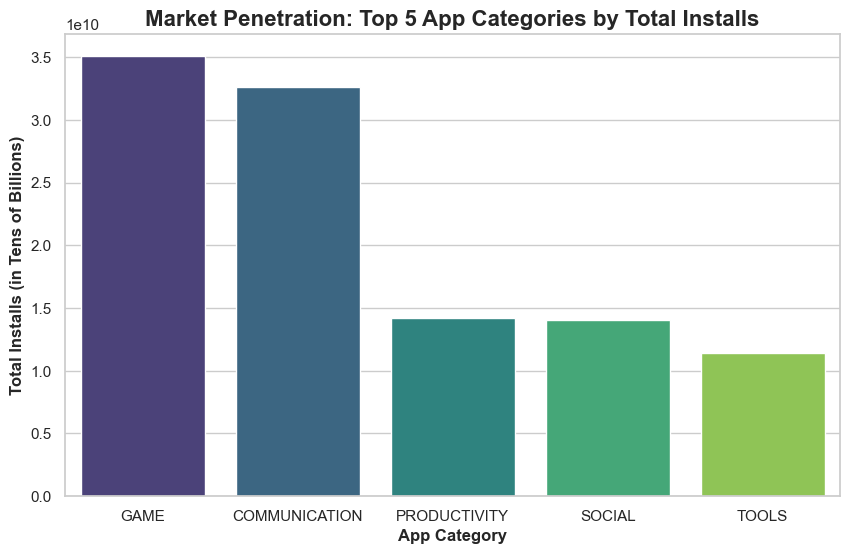

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Visualizations for Market Insights... \n")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Category', 
    y='Total_Installs', 
    data=top_categories, 
    palette='viridis'
)


plt.title('Market Penetration: Top 5 App Categories by Total Installs', fontsize=16, fontweight='bold')
plt.xlabel('App Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Installs (in Tens of Billions)', fontsize=12, fontweight='bold')


plt.show()

In [6]:

print("Initiating Financial Data Cleaning & Analysis... \n")


df['Price'] = df['Price'].str.replace('$', '', regex=False).astype(float)


df.to_sql('apps_table', conn, if_exists='replace', index=False)


query_price = """
SELECT 
    Type, 
    COUNT(App) AS Total_Apps, 
    ROUND(AVG(Rating), 2) AS Average_Rating,
    SUM(Installs) AS Total_Installs
FROM apps_table 
WHERE Type IN ('Free', 'Paid')
GROUP BY Type;
"""


price_analysis = pd.read_sql_query(query_price, conn)
print(price_analysis)

Initiating Financial Data Cleaning & Analysis... 

   Type  Total_Apps  Average_Rating  Total_Installs
0  Free       10039            4.19    167560477406
1  Paid         800            4.27        72956081


Generating Final Scatter Plot: Price vs Rating (Paid Apps)... 📈



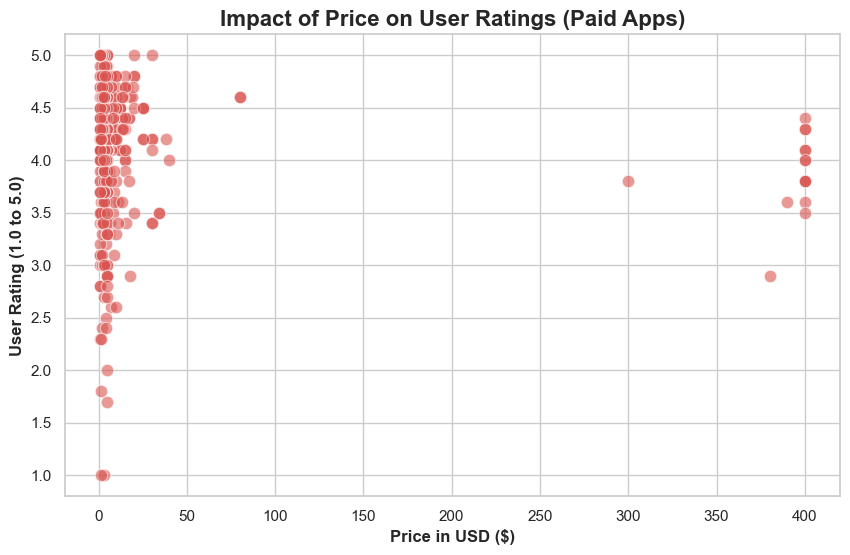

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


print("Generating Final Scatter Plot: Price vs Rating (Paid Apps)... 📈\n")


paid_apps = df[df['Type'] == 'Paid']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


sns.scatterplot(
    x='Price', 
    y='Rating', 
    data=paid_apps, 
    color='#d9534f',
    alpha=0.6,      
    s=80            
)

plt.title('Impact of Price on User Ratings (Paid Apps)', fontsize=16, fontweight='bold')
plt.xlabel('Price in USD ($)', fontsize=12, fontweight='bold')
plt.ylabel('User Rating (1.0 to 5.0)', fontsize=12, fontweight='bold')

plt.show()